## Day 8 – Implementation

*Focus: structured, traceable execution*

In [1]:
# Standalone setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.signal import find_peaks

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

smi_daily = yf.download("^SSMI", period="1y", interval="1d", progress=False)
if isinstance(smi_daily.columns, pd.MultiIndex):
    smi_daily.columns = smi_daily.columns.get_level_values(0)

price = smi_daily['Close'].dropna().values.astype(float)
time_index = smi_daily['Close'].dropna().index

/var/folders/qr/40kwqhb578jfzhtt2nw831h40000gn/T/ipykernel_95097/1312059430.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  smi_daily = yf.download("^SSMI", period="1y", interval="1d", progress=False)


In [2]:
def compute_autocorrelation(signal, max_lag=None, normalized=True):
    """Compute the normalized auto-correlation function."""
    n = len(signal)
    if max_lag is None:
        max_lag = n
    centered = signal - np.mean(signal)
    
    acf = np.zeros(max_lag)
    for tau in range(max_lag):
        acf[tau] = np.sum(centered[:n-tau] * centered[tau:])
    
    if normalized and acf[0] > 0:
        acf /= acf[0]
    return acf


def compute_crosscorrelation(template, signal, normalized=True):
    """Compute the normalized cross-correlation (sliding window)."""
    m = len(template)
    n = len(signal)
    template_centered = template - np.mean(template)
    template_energy = np.sum(template_centered**2)
    
    ccf = np.zeros(n - m + 1)
    for tau in range(n - m + 1):
        segment = signal[tau:tau + m]
        segment_centered = segment - np.mean(segment)
        correlation = np.sum(template_centered * segment_centered)
        
        if normalized:
            segment_energy = np.sum(segment_centered**2)
            denominator = np.sqrt(template_energy * segment_energy)
            ccf[tau] = correlation / denominator if denominator > 0 else 0
        else:
            ccf[tau] = correlation
    return ccf

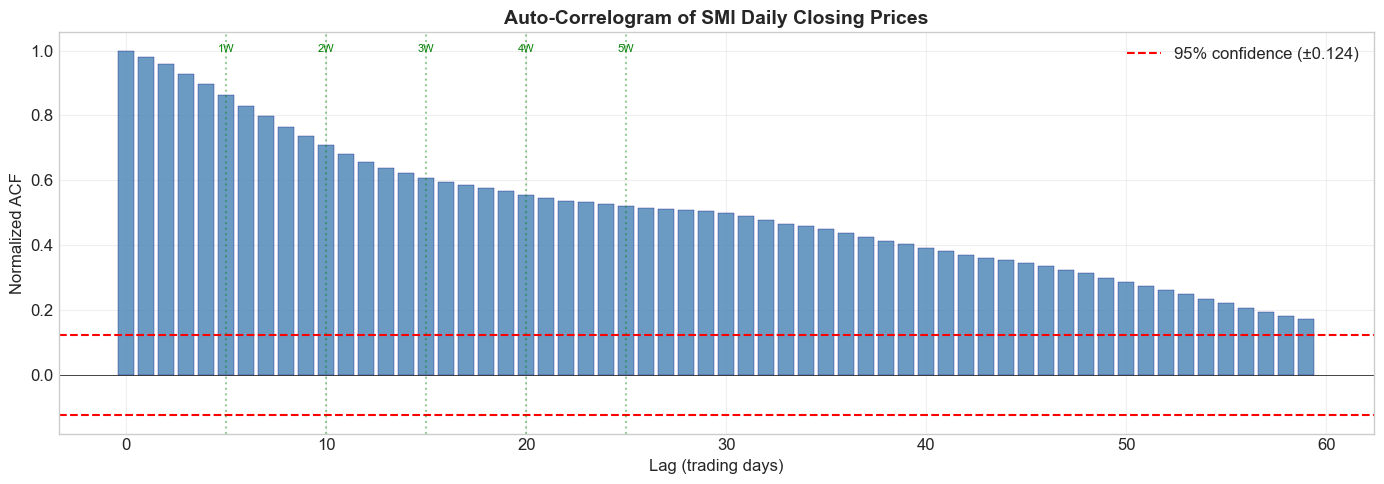

Significant ACF peaks at lags: []


In [3]:
# Auto-correlation analysis
max_lag = 60
acf = compute_autocorrelation(price, max_lag=max_lag, normalized=True)
confidence_band = 1.96 / np.sqrt(len(price))

fig, ax = plt.subplots(figsize=(14, 5))
lags = np.arange(max_lag)
ax.bar(lags, acf, color='steelblue', alpha=0.8, edgecolor='navy', linewidth=0.3)
ax.axhline(y=confidence_band, color='red', linestyle='--', label=f'95% confidence (±{confidence_band:.3f})')
ax.axhline(y=-confidence_band, color='red', linestyle='--')
ax.axhline(y=0, color='black', linewidth=0.5)

for week in [5, 10, 15, 20, 25]:
    if week < max_lag:
        ax.axvline(x=week, color='green', linestyle=':', alpha=0.4)
        ax.text(week, 0.95, f'{week//5}W', ha='center', fontsize=8, color='green',
                transform=ax.get_xaxis_transform())

ax.set_xlabel('Lag (trading days)', fontsize=12)
ax.set_ylabel('Normalized ACF', fontsize=12)
ax.set_title('Auto-Correlogram of SMI Daily Closing Prices', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

peaks, _ = find_peaks(acf[1:], height=confidence_band)
peaks += 1
print(f"Significant ACF peaks at lags: {peaks[:10]}")
for p in peaks[:5]:
    print(f"  Lag {p} ({p/5:.1f} weeks): ACF = {acf[p]:.4f}")

In [4]:
# Cross-correlation: extract template and detect its position
template_start = 50
template_length = 10
template = price[template_start:template_start + template_length]

print(f"Template extracted: positions {template_start}–{template_start + template_length - 1}")
print(f"Template dates: {time_index[template_start].strftime('%Y-%m-%d')} to "
      f"{time_index[template_start + template_length - 1].strftime('%Y-%m-%d')}")

ccf = compute_crosscorrelation(template, price, normalized=True)

# Identify the detected position
detected_pos = np.argmax(ccf)
print(f"\nCross-correlation maximum: {ccf[detected_pos]:.4f} at position {detected_pos}")
print(f"Expected position: {template_start}")
print(f"Detection {'CORRECT' if detected_pos == template_start else 'MISMATCH'}")

Template extracted: positions 50–59
Template dates: 2025-06-03 to 2025-06-17

Cross-correlation maximum: 1.0000 at position 50
Expected position: 50
Detection CORRECT


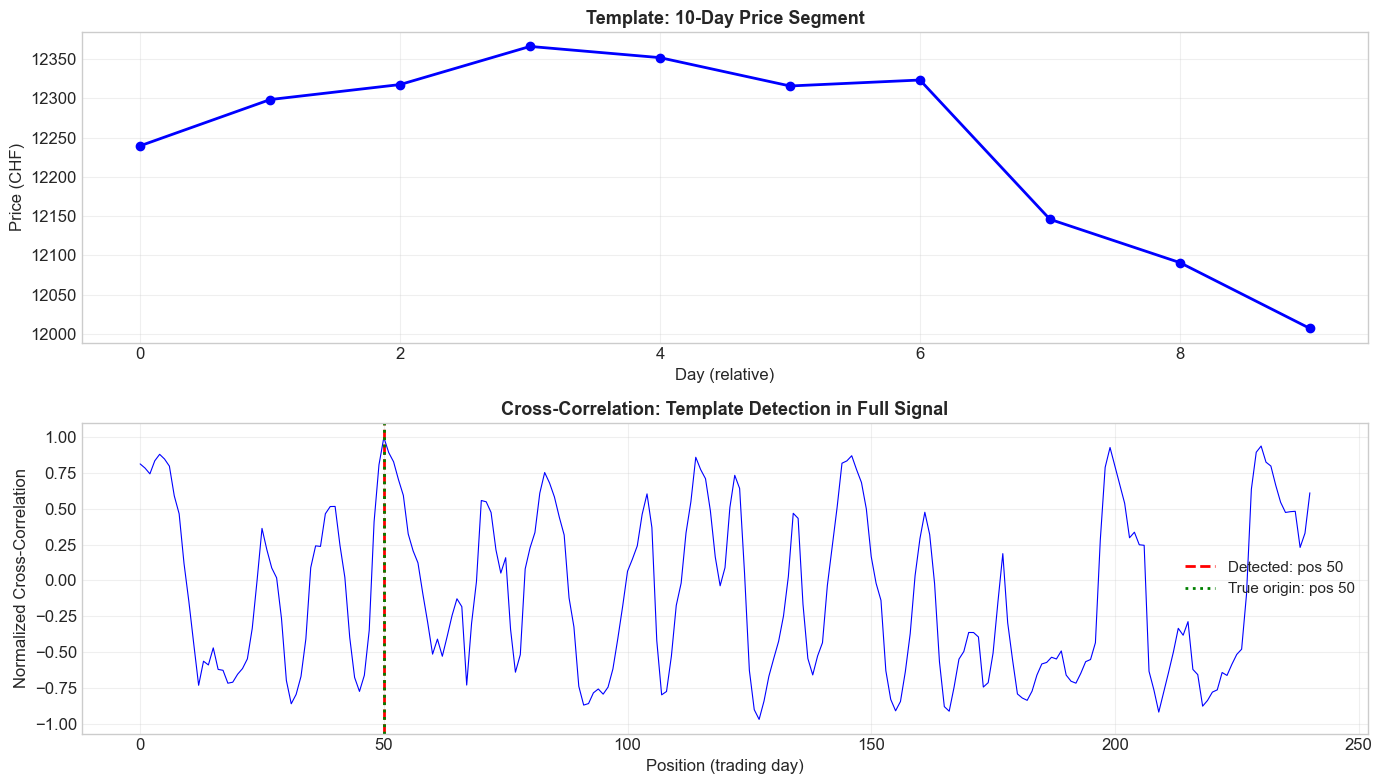

In [5]:
# Visualize cross-correlation result
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

ax1.plot(range(template_length), template, 'b-o', linewidth=2, markersize=6)
ax1.set_xlabel('Day (relative)', fontsize=12)
ax1.set_ylabel('Price (CHF)', fontsize=12)
ax1.set_title(f'Template: {template_length}-Day Price Segment', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(np.arange(len(ccf)), ccf, 'b-', linewidth=0.8)
ax2.axvline(x=detected_pos, color='red', linestyle='--', linewidth=2,
            label=f'Detected: pos {detected_pos}')
ax2.axvline(x=template_start, color='green', linestyle=':', linewidth=2,
            label=f'True origin: pos {template_start}')
ax2.set_xlabel('Position (trading day)', fontsize=12)
ax2.set_ylabel('Normalized Cross-Correlation', fontsize=12)
ax2.set_title('Cross-Correlation: Template Detection in Full Signal', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()